In [1]:
import os
import sys

# Add RF-DETR to path
sys.path.insert(0, "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\rf-detr")

from rfdetr import RFDETRBase
import torch
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# CONFIGURATION
# ============================================================

DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\AlCastDetection-20251015T171832Z-1-001\\AlCastDetection"
OUTPUT_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aicast_multilayer_output"

# Training hyperparameters
EPOCHS = 50
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 16
LEARNING_RATE = 1e-4

In [3]:
# MULTI-LAYER CKA CONFIGURATION
# ============================================================

# CKA Regularization strength
CKA_LAMBDA = 0.5  # Start with 0.5, experiment with 0.3-1.0

# Augmentation strategy
CKA_AUGMENTATION_STRENGTH = 'moderate'  # 'weak', 'moderate', 'strong'

# Progressive weighting
CKA_PROGRESSIVE = True  # Gradually increase CKA weight over first 5 epochs

# Small object focus
CKA_FOCUS_SMALL_OBJECTS = True  # Emphasize higher-resolution layers

# Temperature for CKA scaling
CKA_TEMPERATURE = 1.0  # Higher = softer alignment

print("=" * 60)
print("MULTI-LAYER CKA TRAINING CONFIGURATION")
print("=" * 60)
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Grad Accum: {GRAD_ACCUM_STEPS}")
print(f"\nMulti-Layer CKA Settings:")
print(f"  Lambda (weight): {CKA_LAMBDA}")
print(f"  Augmentation strength: {CKA_AUGMENTATION_STRENGTH}")
print(f"  Progressive weighting: {CKA_PROGRESSIVE}")
print(f"  Small object focus: {CKA_FOCUS_SMALL_OBJECTS}")
print(f"  Temperature: {CKA_TEMPERATURE}")
print("=" * 60)





MULTI-LAYER CKA TRAINING CONFIGURATION
Dataset: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\AlCastDetection-20251015T171832Z-1-001\AlCastDetection
Output: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\aicast_multilayer_output
Epochs: 50, Batch Size: 4, Grad Accum: 16

Multi-Layer CKA Settings:
  Lambda (weight): 0.5
  Augmentation strength: moderate
  Progressive weighting: True
  Small object focus: True
  Temperature: 1.0


In [4]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1
Device name: NVIDIA GeForce RTX 2060


In [5]:
# ============================================================
# INITIALIZE MODEL
# ============================================================

model = RFDETRBase()

Loading pretrain weights


In [6]:
# ============================================================
# START TRAINING
# ============================================================

model.train(
    dataset_dir=DATASET_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    lr=LEARNING_RATE,
    output_dir=OUTPUT_DIR,
    use_ema=True,
    tensorboard=True,  # Enable to visualize layer-wise CKA losses
    early_stopping=True,
    early_stopping_patience=10,
    amp=True,
    device='cuda',
    num_workers=0,
    multi_scale=False,
    resolution=448,
    
    # ============ MULTI-LAYER CKA PARAMETERS ============
    cka_lambda=CKA_LAMBDA,
    cka_augmentation_strength=CKA_AUGMENTATION_STRENGTH,
    cka_progressive=CKA_PROGRESSIVE,
    cka_focus_small_objects=CKA_FOCUS_SMALL_OBJECTS,
    cka_temperature=CKA_TEMPERATURE
)

print("\n✅ Training completed!")
print(f"Model saved to: {OUTPUT_DIR}")


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\aicast_multilayer_output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: f108f8587ac339368a233cb59e7faff800a7c3ed, status: has uncommited changes, branch: develop

Namespace(num_classes=2, grad_accum_steps=16, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=50, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True,


  [CKA Layer Losses - Step 0]
    Layer 0: 0.299504
    Total CKA: 0.000000
    Progressive weight: 0.000

Epoch: [0]  [ 0/37]  eta: 0:13:58  lr: 0.000100  class_error: 100.00  loss: 15.3727 (15.3727)  loss_ce: 0.4266 (0.4266)  loss_bbox: 1.1788 (1.1788)  loss_giou: 1.6740 (1.6740)  loss_ce_0: 0.3680 (0.3680)  loss_bbox_0: 2.3877 (2.3877)  loss_giou_0: 1.5433 (1.5433)  loss_ce_1: 0.3761 (0.3761)  loss_bbox_1: 1.2816 (1.2816)  loss_giou_1: 1.7845 (1.7845)  loss_ce_enc: 0.3705 (0.3705)  loss_bbox_enc: 2.3865 (2.3865)  loss_giou_enc: 1.5951 (1.5951)  loss_cka: 0.0000 (0.0000)  loss_ce_unscaled: 0.4266 (0.4266)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.2358 (0.2358)  loss_giou_unscaled: 0.8370 (0.8370)  cardinality_error_unscaled: 1.5000 (1.5000)  loss_ce_0_unscaled: 0.3680 (0.3680)  loss_bbox_0_unscaled: 0.4775 (0.4775)  loss_giou_0_unscaled: 0.7717 (0.7717)  cardinality_error_0_unscaled: 1.0000 (1.0000)  loss_ce_1_unscaled: 0.3761 (0.3761)  loss_bbox_1_unscaled: 

In [7]:
def parse_multilayer_cka_logs(log_file):
    """Parse log file and extract multi-layer CKA metrics"""
    
    epochs = []
    cka_total = []
    cka_layer_0 = []
    cka_layer_1 = []
    cka_layer_2 = []
    progressive_weights = []
    
    with open(log_file, 'r') as f:
        for line in f:
            data = json.loads(line.strip())
            
            epochs.append(data.get('epoch', 0))
            cka_total.append(data.get('loss_cka_total', 0))
            cka_layer_0.append(data.get('loss_cka_layer_0', 0))
            cka_layer_1.append(data.get('loss_cka_layer_1', 0))
            cka_layer_2.append(data.get('loss_cka_layer_2', 0))
            progressive_weights.append(data.get('loss_progressive_weight', 1.0))
    
    return {
        'epochs': epochs,
        'cka_total': cka_total,
        'cka_layer_0': cka_layer_0,
        'cka_layer_1': cka_layer_1,
        'cka_layer_2': cka_layer_2,
        'progressive_weights': progressive_weights
    }

In [11]:
# Load data
log_file = "D:/Ruturaj/New folder (3)/Ruturaj/Smart Systems/rfdetr/RFDETR/aicast_multilayer_output/log.txt"
data = parse_multilayer_cka_logs(log_file)


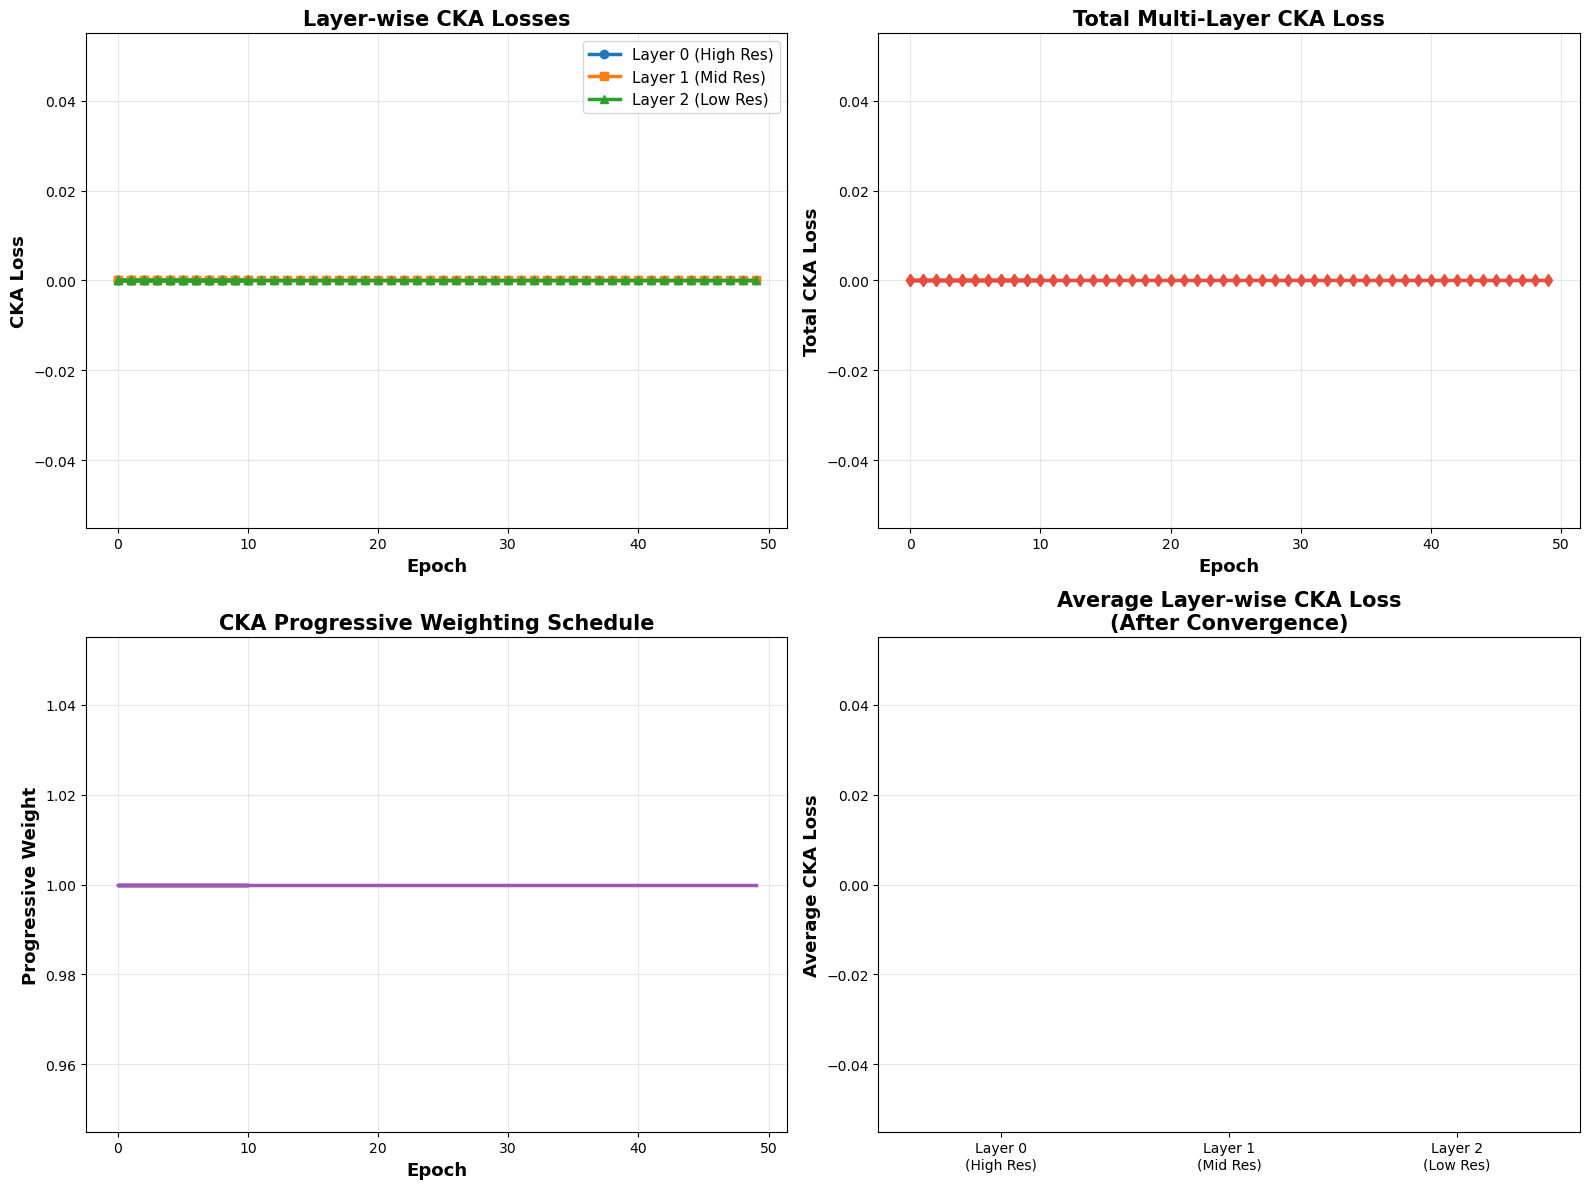

✓ Multi-layer CKA analysis plot saved


In [20]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Layer-wise CKA losses
ax1 = axes[0, 0]
ax1.plot(data['epochs'], data['cka_layer_0'], label='Layer 0 (High Res)', linewidth=2.5, marker='o')
ax1.plot(data['epochs'], data['cka_layer_1'], label='Layer 1 (Mid Res)', linewidth=2.5, marker='s')
ax1.plot(data['epochs'], data['cka_layer_2'], label='Layer 2 (Low Res)', linewidth=2.5, marker='^')
ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('CKA Loss', fontsize=13, fontweight='bold')
ax1.set_title('Layer-wise CKA Losses', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Total CKA loss
ax2 = axes[0, 1]
ax2.plot(data['epochs'], data['cka_total'], color='#e74c3c', linewidth=2.5, marker='d')
ax2.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax2.set_ylabel('Total CKA Loss', fontsize=13, fontweight='bold')
ax2.set_title('Total Multi-Layer CKA Loss', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Progressive weighting
ax3 = axes[1, 0]
ax3.plot(data['epochs'], data['progressive_weights'], color='#9b59b6', linewidth=2.5)
ax3.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax3.set_ylabel('Progressive Weight', fontsize=13, fontweight='bold')
ax3.set_title('CKA Progressive Weighting Schedule', fontsize=15, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Layer importance (average over training)
ax4 = axes[1, 1]
avg_layer_losses = [
    np.mean(data['cka_layer_0'][5:]),  # Skip first 5 epochs
    np.mean(data['cka_layer_1'][5:]),
    np.mean(data['cka_layer_2'][5:])
]
ax4.bar(['Layer 0\n(High Res)', 'Layer 1\n(Mid Res)', 'Layer 2\n(Low Res)'], 
        avg_layer_losses, color=['#3498db', '#2ecc71', '#f39c12'])
ax4.set_ylabel('Average CKA Loss', fontsize=13, fontweight='bold')
ax4.set_title('Average Layer-wise CKA Loss\n(After Convergence)', fontsize=15, fontweight='bold')
ax4.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('multilayer_cka_analysis.png', dpi=300)
plt.show()

print("✓ Multi-layer CKA analysis plot saved")



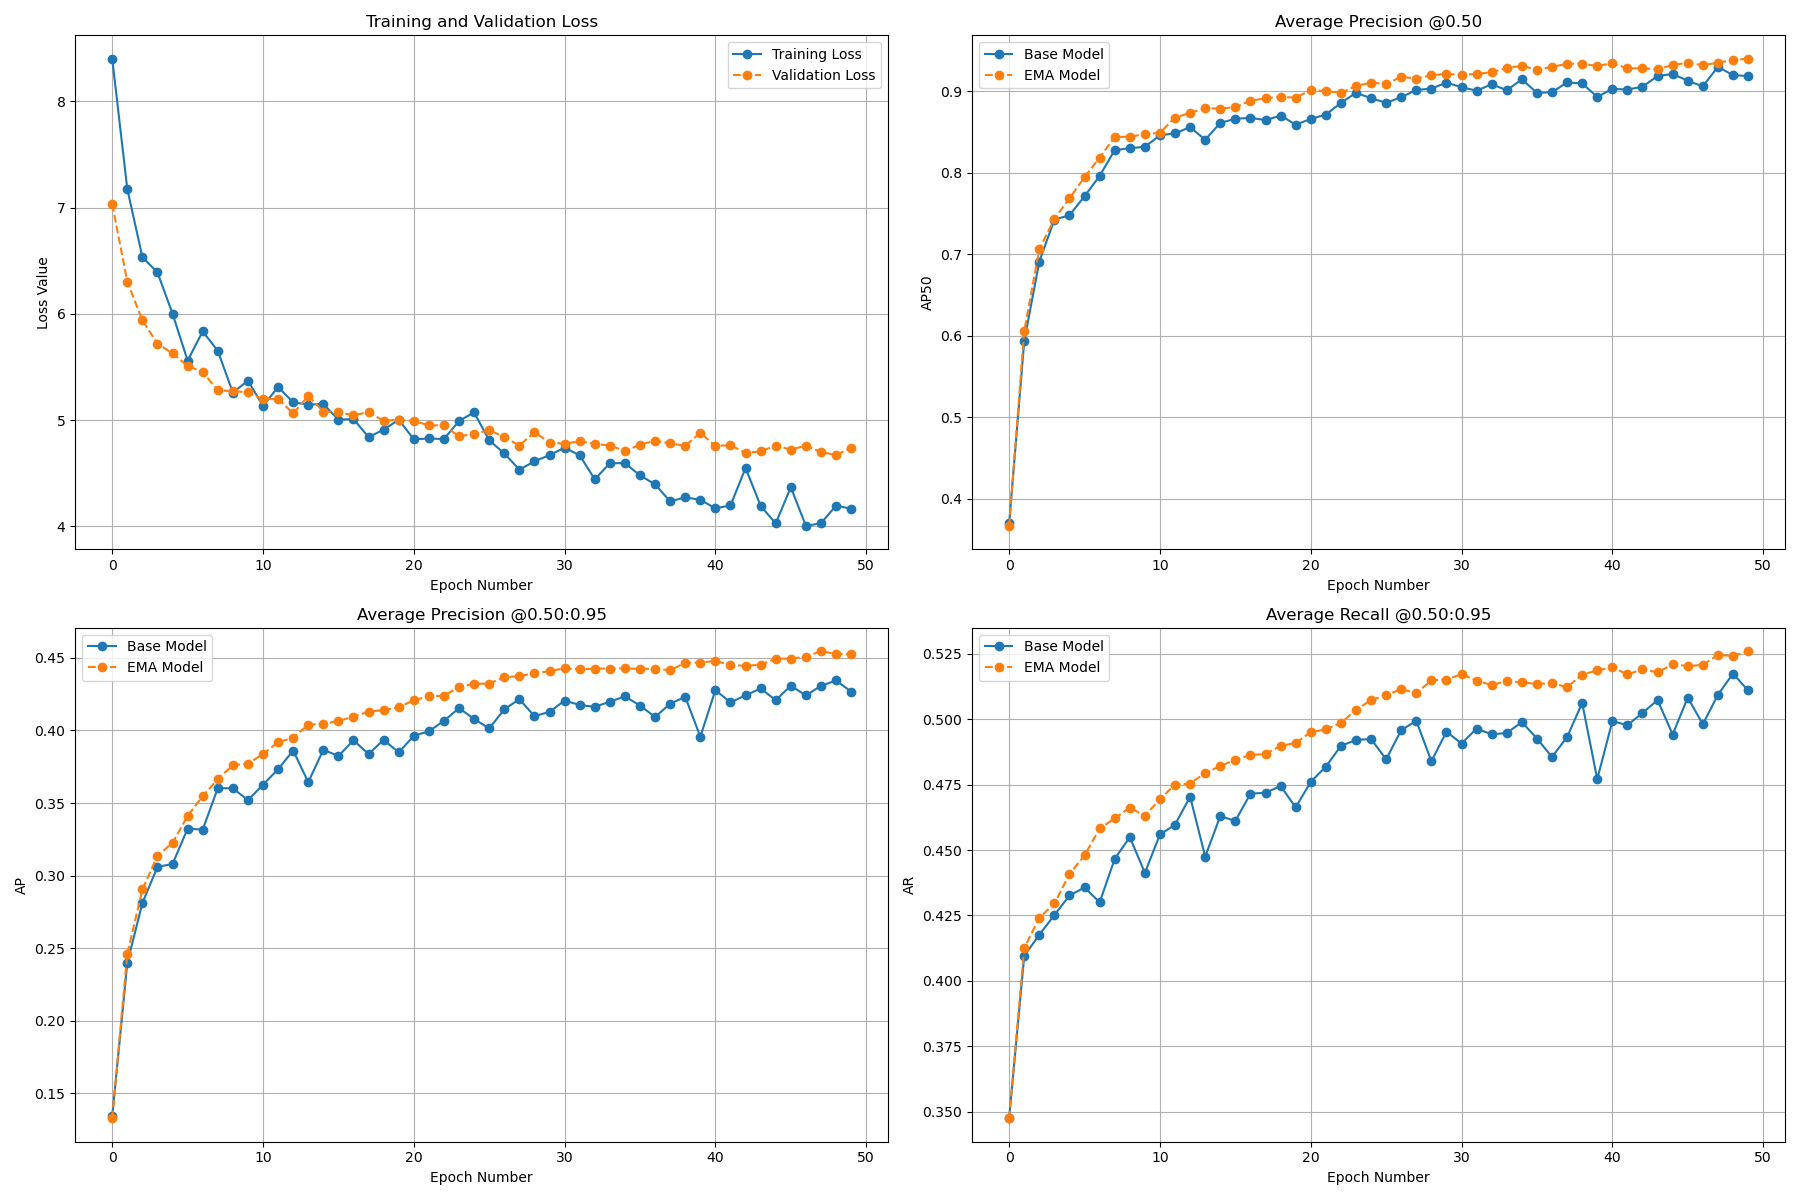

In [21]:
from PIL import Image

Image.open("D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aicast_multilayer_output\\metrics_plot.png")


In [22]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [23]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 138.46 MB | Reserved: 4684.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 138.46 MB | Reserved: 280.00 MB


In [24]:
model = RFDETRBase(pretrain_weights="D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aicast_multilayer_output\\checkpoint_best_total.pth")

Loading pretrain weights


In [25]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{DATASET_DIR}/test",
    annotations_path=f"{DATASET_DIR}/test/_annotations.coco.json",
)

In [26]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

model.optimize_for_inference()
targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    # Open and convert image to RGB (ensures 3 channels)
    image = Image.open(path).convert('RGB')  # This fixes the channel issue
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
100%|██████████| 346/346 [00:34<00:00,  9.95it/s]


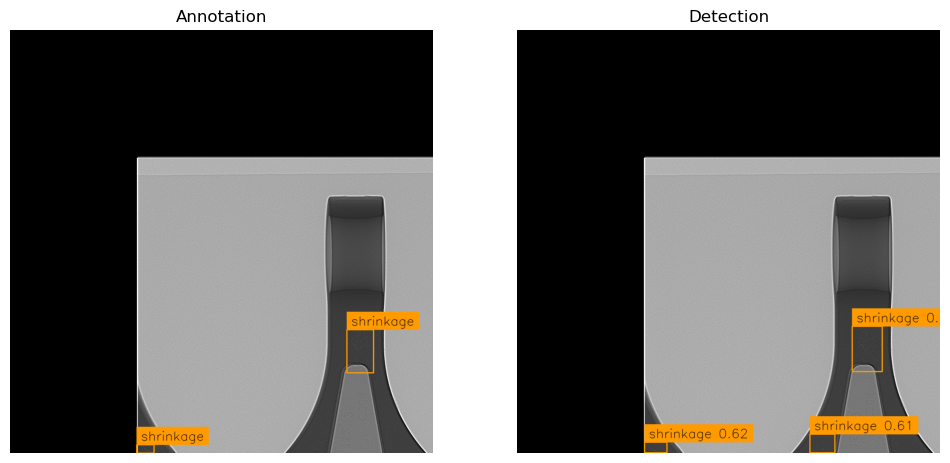

In [27]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])